# Web Scraping Job Vacancies

# Global Job Market Intelligence Pipeline (Adzuna API)

### Automated Job Scraping, Cleaning, Normalization & Analytics System

This project extracts job listings from the Adzuna API across multiple countries, processes and cleans the data, and generates structured insights including companies, skills, countries, and regional job distribution.

## Project Overview

This pipeline automates end-to-end job market data analysis:

- Job scraping from Adzuna API
- Data cleaning and normalization
- Country and region standardization
- Skill extraction using NLP-based matching
- Statistical aggregation and visualization

The goal is to provide **real-world recruitment intelligence insights**.

In [3]:
import requests
import pandas as pd
import re
import os
import logging
import matplotlib.pyplot as plt
from dotenv import load_dotenv

load_dotenv()

APP_ID = os.getenv("ADZUNA_APP_ID")
APP_KEY = os.getenv("ADZUNA_APP_KEY")

BASE_URL = "https://api.adzuna.com/v1/api/jobs"
COUNTRIES = ["gb", "us", "ca", "de", "fr"]

KEYWORDS = [
    "python developer",
    "data analyst",
    "software engineer",
    "backend developer",
    "devops engineer"
]

SKILLS = [
    "python","sql","aws","docker","git",
    "react","javascript","java","excel","linux","machine learning"
]

COUNTRY_MAP = {
    "gb": "United Kingdom",
    "us": "United States",
    "ca": "Canada",
    "de": "Germany",
    "fr": "France"
}

logging.basicConfig(
    filename="scraper.log",
    level=logging.INFO,
    format="%(asctime)s - %(message)s"
)

In [4]:
def fetch_jobs(pages=3):
    results = []

    for country in COUNTRIES:
        for kw in KEYWORDS:
            for page in range(1, pages + 1):
                try:
                    url = f"{BASE_URL}/{country}/search/{page}"
                    params = {
                        "app_id": APP_ID,
                        "app_key": APP_KEY,
                        "results_per_page": 50,
                        "what": kw
                    }
                    r = requests.get(url, params=params, timeout=20)
                    if r.status_code == 200:
                        jobs = r.json().get("results", [])
                        for j in jobs:
                            j["api_country"] = country
                        results.extend(jobs)
                except:
                    continue

    return results

In [5]:
def extract_skills(text):
    text = str(text).lower()
    return [s for s in SKILLS if re.search(rf"\b{s}\b", text)]


def extract_region(location_obj):

    if isinstance(location_obj, dict):
        display = location_obj.get("display_name", "")
    else:
        display = str(location_obj)

    txt = display.lower().strip()

    if "remote" in txt:
        return "Remote"

    parts = [p.strip() for p in txt.split(",")]
    city = parts[0] if parts else ""


    city = city.replace("münchen", "munich")
    city = city.replace("montréal", "montreal")

    FIXES = {
        "central london": "London",
        "the city": "London",
        "greater vancouver": "Vancouver"
    }

    city = FIXES.get(city, city)

    
    INVALID = [
        "deutschland", "germany", "france", "canada",
        "uk", "us", "united kingdom", "united states",
        "arrondissement"
    ]

    if any(x in city for x in INVALID):
        return "Unknown"

    return city.title() if city else "Unknown"


def parse(data):
    rows = []

    for j in data:
        try:
            loc = j.get("location") or {}
            area = loc.get("area", [])
            api_country = (j.get("api_country") or "").lower()

            country = COUNTRY_MAP.get(api_country)

            if not country:
                if isinstance(area, list) and len(area) > 0:
                    country = COUNTRY_MAP.get(str(area[0]).lower(), "Unknown")
                else:
                    country = "Unknown"

            desc = j.get("description", "") or ""
            skills = extract_skills(desc)

            rows.append({
                "title": j.get("title", ""),
                "company": (j.get("company") or {}).get("display_name", "Unknown"),
                "location": loc.get("display_name", ""),
                "country": country,
                "region": extract_region(loc),
                "skills": ",".join(skills)
            })

        except:
            continue

    df = pd.DataFrame(rows).drop_duplicates()

    if df.empty:
        raise ValueError("No data parsed")

    return df

In [6]:
def analyze(df):

    print("\nTOTAL JOBS:", len(df))

    companies = df["company"].value_counts().head(10)

    skills = (
        df["skills"]
        .str.split(",")
        .explode()
        .replace("", pd.NA)
        .dropna()
        .value_counts()
        .head(10)
    )

    df["country"] = df["country"].astype(str).str.strip()
    df = df[df["country"] != "Unknown"]
    countries = df["country"].value_counts()

    df["region"] = df["region"].astype(str).str.strip()
    df = df[df["region"] != "Unknown"]
    regions = df["region"].value_counts().head(15)

    print("\nTOP COMPANIES")
    print(companies)

    print("\nTOP SKILLS")
    print(skills)

    print("\nTOP COUNTRIES")
    print(countries)

    print("\nTOP REGIONS")
    print(regions)

    return companies, skills, countries, regions


TOTAL JOBS: 3532

TOP COMPANIES
Lockheed Martin                      194
Targeted Talent                       79
Insight Global                        59
ITOL Recruit                          55
Datev eG                              45
Mindrift                              41
Cognizant                             36
Sennheiser electronic SE & Co. KG     36
KIND GmbH & Co. KG                    35
Noir                                  32
Name: company, dtype: int64

TOP SKILLS
python              460
java                149
aws                 127
docker               84
linux                79
sql                  65
react                53
machine learning     31
javascript           26
excel                26
Name: skills, dtype: int64

TOP COUNTRIES
United States     741
France            721
United Kingdom    713
Germany           686
Canada            671
Name: country, dtype: int64

TOP REGIONS
London                 185
Paris                  169
Toronto                139
Ber

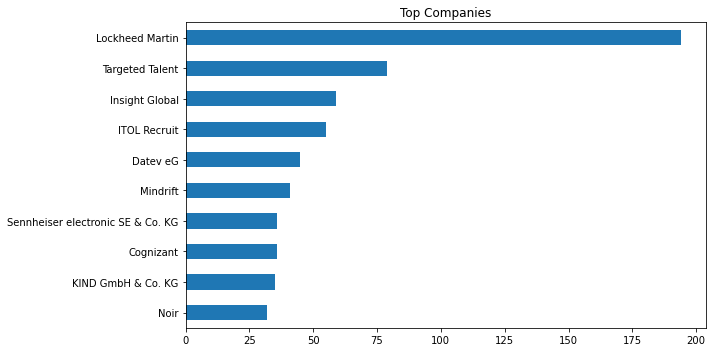

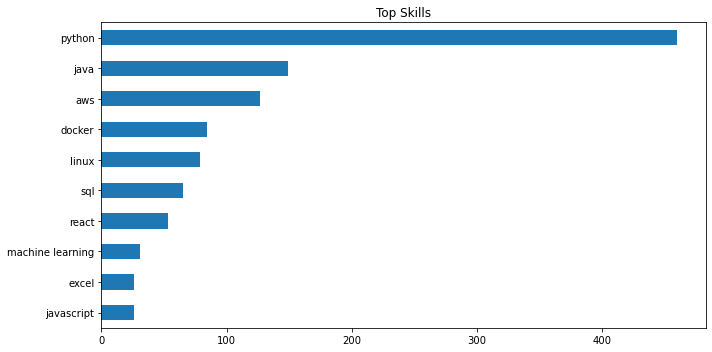

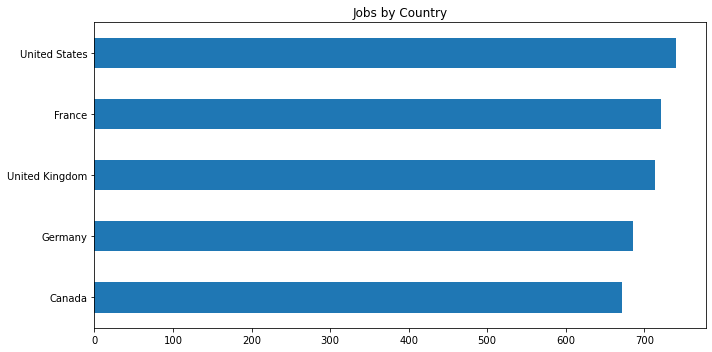

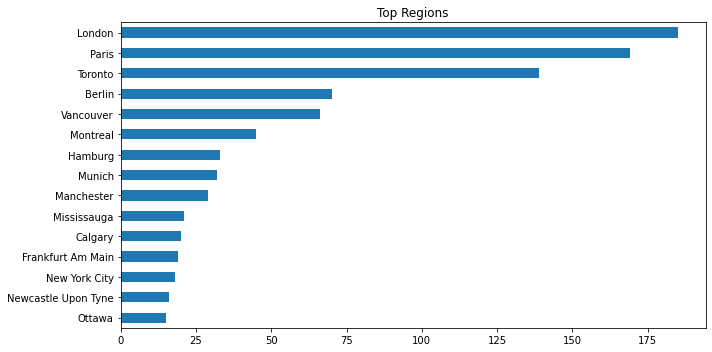

In [7]:
def plot(c, s, countries, regions):

    plt.figure(figsize=(10,5))
    c.sort_values().plot(kind="barh")
    plt.title("Top Companies")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10,5))
    s.sort_values().plot(kind="barh")
    plt.title("Top Skills")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10,5))
    countries.sort_values().plot(kind="barh")
    plt.title("Jobs by Country")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10,5))
    regions.sort_values().plot(kind="barh")
    plt.title("Top Regions")
    plt.tight_layout()
    plt.show()


data = fetch_jobs(pages=3)
df = parse(data)

df.to_csv("jobs_cleaned.csv", index=False)

c, s, countries, regions = analyze(df)

plot(c, s, countries, regions)

## Key Insights

### Total Jobs Scraped
- **3,532 job listings processed**

---

### Top Hiring Companies
- Lockheed Martin  
- Targeted Talent  
- Insight Global  
- ITOL Recruit  
- Datev eG  

---

### Most In-Demand Skills
- Python  
- Java  
- AWS  
- Docker  
- Linux  

---

### Job Distribution by Country
- United States  
- France  
- United Kingdom  
- Germany  
- Canada  

---

### Top Hiring Regions
- London  
- Paris  
- Toronto  
- Berlin  
- Vancouver  
- Montreal  

## Approach

This project follows a structured end-to-end data pipeline approach to extract, clean, and analyze global job market data using the Adzuna API.

### 1. Data Collection
Job listings are collected from the Adzuna API across multiple countries and job keywords using HTTP requests. The scraper iterates through different endpoints to gather a large and diverse dataset of job postings.

### 2. Data Extraction
From each job posting, key attributes are extracted including:
- Job title
- Company name
- Location
- Country
- Job description
- Posting metadata

### 3. Data Cleaning & Normalization
The raw dataset is cleaned to ensure consistency:
- Removal of duplicates
- Handling missing values
- Standardizing text formatting
- Mapping country codes to readable country names
- Extracting structured regions from location fields

### 4. Feature Engineering
Additional insights are generated from raw text data:
- Skill extraction using keyword matching (Python, AWS, SQL, etc.)
- Region-level classification from location data
- Aggregation-ready structured fields

### 5. Analysis & Visualization
The cleaned dataset is analyzed to generate insights such as:
- Top hiring companies
- Most in-demand skills
- Job distribution by country
- Top hiring regions

Visualizations are created using bar charts for better interpretability.

---

## Conclusion

This project demonstrates a complete data engineering workflow from raw API data extraction to structured business insights.

The final output provides a clear view of global job market trends, highlighting key hiring companies, in-demand technical skills, and geographical job distribution patterns.

Overall, this system can be extended into a real-time job intelligence dashboard, supporting recruitment analytics, market research, and career trend analysis.